In [1]:
import pandas as pd
import os

# Ensure folders exist (important)
os.makedirs("Data_Preparation", exist_ok=True)
os.makedirs("Clustering_Analysis", exist_ok=True)

In [2]:
df = pd.read_csv("Dataset_ATS_v2.csv")

df.head()

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gender           7043 non-null   object
 1   SeniorCitizen    7043 non-null   int64 
 2   Dependents       7043 non-null   object
 3   tenure           7043 non-null   int64 
 4   PhoneService     7043 non-null   object
 5   MultipleLines    7043 non-null   object
 6   InternetService  7043 non-null   object
 7   Contract         7043 non-null   object
 8   MonthlyCharges   7043 non-null   int64 
 9   Churn            7043 non-null   object
dtypes: int64(3), object(7)
memory usage: 357.7+ KB


gender             0
SeniorCitizen      0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
Contract           0
MonthlyCharges     0
Churn              0
dtype: int64

In [4]:
# Fill numeric columns
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,Contract_One year,Contract_Two year,Churn_Yes
0,0,1,25,False,False,False,False,False,False,False,True
1,0,41,25,True,False,True,False,False,True,False,False
2,0,52,19,False,True,True,False,False,False,False,False
3,0,1,76,False,False,True,False,False,True,False,True
4,0,67,51,True,False,True,False,True,False,False,False


In [6]:
df_encoded.to_csv("Data_Preparation/preprocessed_dataset.csv", index=False)

In [7]:
df_encoded.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'gender_Male',
       'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'Contract_One year', 'Contract_Two year',
       'Churn_Yes'],
      dtype='object')

In [8]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
X_train.to_csv("Data_Preparation/X_train.csv", index=False)
X_test.to_csv("Data_Preparation/X_test.csv", index=False)
y_train.to_csv("Data_Preparation/y_train.csv", index=False)
y_test.to_csv("Data_Preparation/y_test.csv", index=False)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
pd.DataFrame(X_train_scaled, columns=X_train.columns).to_csv(
    "Data_Preparation/X_train_scaled.csv", index=False
)

pd.DataFrame(X_test_scaled, columns=X_test.columns).to_csv(
    "Data_Preparation/X_test_scaled.csv", index=False
)

In [12]:
os.listdir("Data_Preparation")

['X_test.csv',
 'X_test_scaled.csv',
 'X_train.csv',
 'X_train_scaled.csv',
 'preprocessed_dataset.csv',
 'y_test.csv',
 'y_train.csv']

/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


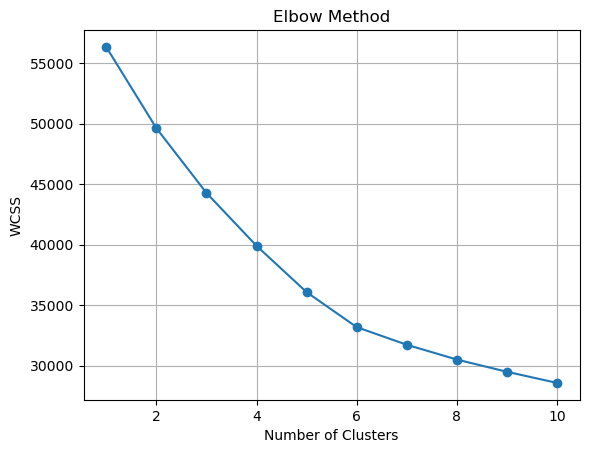

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.savefig("Clustering_Analysis/elbow_method.png")
plt.show()

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_train_scaled)

In [15]:
X_train_clustered = X_train.copy()
X_train_clustered['Cluster'] = clusters

cluster_profile = X_train_clustered.groupby('Cluster').mean()

print(cluster_profile)

         SeniorCitizen     tenure  MonthlyCharges  gender_Male  \
Cluster                                                          
0             0.149457  32.636413       66.790761     0.527717   
1             0.187442  33.572484       66.674977     0.485688   
2             0.158182  32.321818       41.981818     0.516364   
3             0.161499  31.824155       67.780194     0.491902   

         Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
Cluster                                                        
0              0.316304               1.0           0.621739   
1              0.309326               1.0           0.431210   
2              0.292727               0.0           0.405455   
3              0.276261               1.0           0.260528   

         InternetService_Fiber optic  Contract_One year  Contract_Two year  
Cluster                                                                     
0                           1.000000           0.000000         

In [16]:
cluster_analysis = X_train.copy()
cluster_analysis['Cluster'] = clusters
cluster_analysis['Churn'] = y_train.values

churn_by_cluster = cluster_analysis.groupby('Cluster')['Churn'].mean()

print(churn_by_cluster)

Cluster
0    0.263587
1    0.253001
2    0.243636
3    0.281814
Name: Churn, dtype: float64


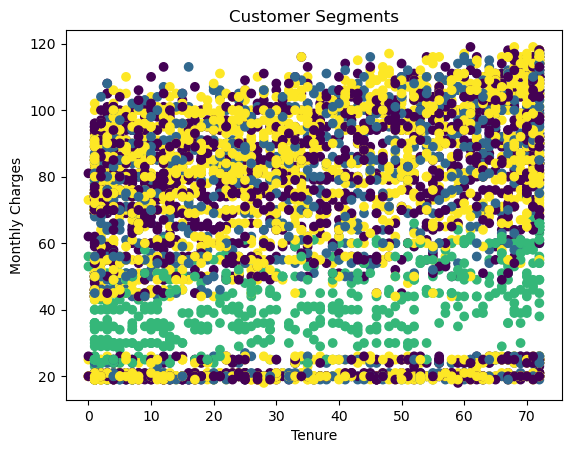

In [17]:
plt.scatter(
    X_train["tenure"], 
    X_train["MonthlyCharges"], 
    c=clusters
)

plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.title("Customer Segments")

plt.savefig("Clustering_Analysis/cluster_visualisation.png")
plt.show()

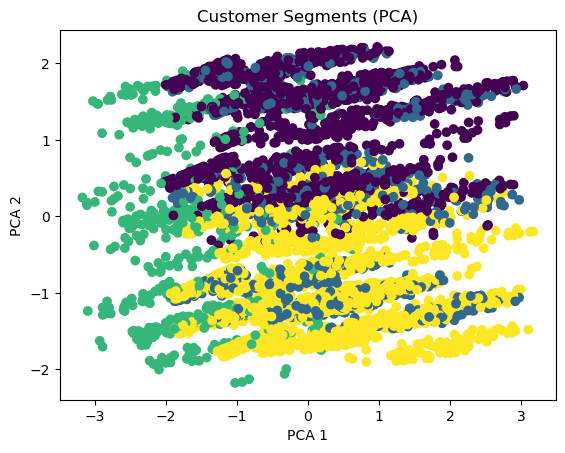

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)

plt.title("Customer Segments (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.savefig("Clustering_Analysis/cluster_visualisation.png")
plt.show()

## Model Building and Evaluation

The three models compared in this section are Logistic Regression, Random Forest, and ANN.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

model_results = []
roc_results = {}

In [ ]:
# Logistic Regression
# Logistic Regression works better with scaled data.

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)
auc_log = roc_auc_score(y_test, log_prob)

model_results.append({
    "Model": "Logistic Regression",
    "Accuracy": log_accuracy,
    "Precision": log_precision,
    "Recall": log_recall,
    "F1 Score": log_f1,
    "AUC": auc_log
})

roc_results["Logistic Regression"] = {
    "probabilities": log_prob,
    "auc": auc_log
}

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy:", round(log_accuracy, 4))
print("Precision:", round(log_precision, 4))
print("Recall:", round(log_recall, 4))
print("F1 Score:", round(log_f1, 4))
print("AUC:", round(auc_log, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_pred))

print("\nClassification Report:")
print(classification_report(y_test, log_pred))

In [ ]:
# Random Forest
# Random Forest is a tree-based model, so it does not need scaled data.

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
auc_rf = roc_auc_score(y_test, rf_prob)

model_results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "AUC": auc_rf
})

roc_results["Random Forest"] = {
    "probabilities": rf_prob,
    "auc": auc_rf
}

print("Random Forest Results")
print("---------------------")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1 Score:", round(rf_f1, 4))
print("AUC:", round(auc_rf, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

In [ ]:
# Artificial Neural Network (ANN)
# In scikit-learn, an ANN for classification is implemented using MLPClassifier.
# This is kept as the ANN model, not as a separate MLP model.

ann_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

ann_model.fit(X_train_scaled, y_train)

ann_pred = ann_model.predict(X_test_scaled)
ann_prob = ann_model.predict_proba(X_test_scaled)[:, 1]

ann_accuracy = accuracy_score(y_test, ann_pred)
ann_precision = precision_score(y_test, ann_pred)
ann_recall = recall_score(y_test, ann_pred)
ann_f1 = f1_score(y_test, ann_pred)
auc_ann = roc_auc_score(y_test, ann_prob)

model_results.append({
    "Model": "ANN",
    "Accuracy": ann_accuracy,
    "Precision": ann_precision,
    "Recall": ann_recall,
    "F1 Score": ann_f1,
    "AUC": auc_ann
})

roc_results["ANN"] = {
    "probabilities": ann_prob,
    "auc": auc_ann
}

print("ANN Results")
print("-----------")
print("Accuracy:", round(ann_accuracy, 4))
print("Precision:", round(ann_precision, 4))
print("Recall:", round(ann_recall, 4))
print("F1 Score:", round(ann_f1, 4))
print("AUC:", round(auc_ann, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, ann_pred))

print("\nClassification Report:")
print(classification_report(y_test, ann_pred))

In [ ]:
# Model comparison table

comparison_df = pd.DataFrame(model_results)
comparison_df = comparison_df.round(4)

print(comparison_df)

In [ ]:
# Bar chart comparison of model performance

comparison_df.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "AUC"
]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Comparison - Customer Churn Prediction")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Logistic Regression feature importance
# Coefficients show the direction and strength of each feature's effect.

log_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

log_importance["Abs_Coefficient"] = abs(log_importance["Coefficient"])

log_importance = log_importance.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

print(log_importance.head(10))

In [ ]:
# Random Forest feature importance
# Feature importance shows which variables were most useful for decision splits.

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print(rf_importance.head(10))

In [ ]:
# ROC Curve comparison for all three models

plt.figure(figsize=(10, 7))

for model_name, result in roc_results.items():
    fpr, tpr, _ = roc_curve(y_test, result["probabilities"])
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{model_name} (AUC = {result["auc"]:.3f})'
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Customer Churn Prediction Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("AUC Scores")
print("----------")
for model_name, result in roc_results.items():
    print(f"{model_name}: {result['auc']:.4f}")

In [ ]:
# Final recommendations based on the analysis

recommendations = [
    "Focus retention efforts on customers with short tenure.",
    "Offer loyalty discounts or support plans to customers with high monthly charges.",
    "Target the cluster with the highest churn rate.",
    "Use the best-performing model to identify customers with a high risk of churn."
]

for rec in recommendations:
    print(rec)

## Stage 3 — Saving Trained Models and Scaler

In [ ]:
import joblib
import os

os.makedirs("Predictive_Modeling", exist_ok=True)

# Save the trained ANN model
joblib.dump(ann_model, "Predictive_Modeling/ann_model.pkl")
print("ANN model saved: Predictive_Modeling/ann_model.pkl")

# Save the scaler (required to preprocess new data before inference)
joblib.dump(scaler, "Predictive_Modeling/scaler.pkl")
print("Scaler saved:    Predictive_Modeling/scaler.pkl")

# Save supporting models for completeness
joblib.dump(log_model, "Predictive_Modeling/logistic_regression_model.pkl")
joblib.dump(rf_model,  "Predictive_Modeling/random_forest_model.pkl")
print("Logistic Regression model saved.")
print("Random Forest model saved.")

In [ ]:
# Verify all saved files
print("Files in Predictive_Modeling/:")
for f in sorted(os.listdir("Predictive_Modeling")):
    size_kb = os.path.getsize(f"Predictive_Modeling/{f}") / 1024
    print(f"  {f:<45} {size_kb:.1f} KB")

In [ ]:
# Reload and verify the ANN model produces identical predictions
ann_model_loaded = joblib.load("Predictive_Modeling/ann_model.pkl")
scaler_loaded    = joblib.load("Predictive_Modeling/scaler.pkl")

# Run predictions using the reloaded model
ann_pred_verify = ann_model_loaded.predict(X_test_scaled)

import numpy as np
match = np.array_equal(ann_pred, ann_pred_verify)
print(f"Predictions match original: {match}")
print(f"Reloaded model accuracy: {accuracy_score(y_test, ann_pred_verify):.4f}")

In [ ]:
# ANN model summary — architecture confirmation
print("=== ANN Model Architecture ===")
print(f"Hidden layer sizes : {ann_model.hidden_layer_sizes}")
print(f"Activation function: {ann_model.activation}")
print(f"Solver (optimiser) : {ann_model.solver}")
print(f"Max iterations     : {ann_model.max_iter}")
print(f"Actual iterations  : {ann_model.n_iter_}")
print(f"Number of layers   : {ann_model.n_layers_}")
print(f"Number of outputs  : {ann_model.n_outputs_}")
print(f"Output activation  : {ann_model.out_activation_}")
print()
print("Layer weight shapes (input → hidden → output):")
for i, (w, b) in enumerate(zip(ann_model.coefs_, ann_model.intercepts_)):
    label = "Input→H1" if i==0 else (f"H{i}→H{i+1}" if i < len(ann_model.coefs_)-1 else f"H{i}→Output")
    print(f"  Layer {i+1} ({label}): weights {w.shape}, biases {b.shape}")

In [ ]:
# Churn probability scores for the test set — saved for reporting
churn_proba_df = pd.DataFrame({
    "Actual_Churn":       y_test.values,
    "Predicted_Churn":    ann_pred,
    "Churn_Probability":  ann_prob
})

churn_proba_df.to_csv("Predictive_Modeling/ann_churn_predictions.csv", index=False)
print("Churn predictions saved: Predictive_Modeling/ann_churn_predictions.csv")
print()
print(churn_proba_df.head(10).to_string(index=False))

In [ ]:
# Confusion matrix visualisation — ANN only
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, ann_pred)
fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted: No Churn", "Predicted: Churn"])
ax.set_yticklabels(["Actual: No Churn", "Actual: Churn"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > cm.max() / 2 else "black")

ax.set_title("ANN Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("Predictive_Modeling/ann_confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved.")